In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/abozeidmohamed/original-dataset1/encoded_labels_original (4).npy
/kaggle/input/datasets/abozeidmohamed/original-dataset1/label_encoder_classes (2).npy
/kaggle/input/datasets/abozeidmohamed/original-dataset1/images_original (2).npy


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split

# --- تحميل البيانات --- ✅ الترتيب الصح
X = np.load('/kaggle/input/datasets/abozeidmohamed/original-dataset1/images_original (2).npy')        # ← الصور
y = np.load('/kaggle/input/datasets/abozeidmohamed/original-dataset1/encoded_labels_original (4).npy')  # ← اللابيلز

# لو الصور رمادية نكررها لثلاث قنوات
if X.shape[-1] == 1:
    X = np.repeat(X, 3, axis=-1)

# ─── التقسيم الثلاثي 70 / 15 / 15 ───────────────────────────
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, stratify=y_temp, random_state=42
)

# ─── التحقق ──────────────────────────────────────────────────
total = len(X)
print(f"Total  samples : {total}")
print(f"Train  samples : {len(X_train)}  ({len(X_train)/total*100:.1f}%)")
print(f"Val    samples : {len(X_val)}   ({len(X_val)/total*100:.1f}%)")
print(f"Test   samples : {len(X_test)}  ({len(X_test)/total*100:.1f}%)")

input_shape = X_train.shape[1:]
num_classes = len(np.unique(y))

2026-06-19 08:15:33.090480: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781856933.276863      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781856933.325388      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781856933.747234      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781856933.747275      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781856933.747278      57 computation_placer.cc:177] computation placer alr

Total  samples : 42718
Train  samples : 29901  (70.0%)
Val    samples : 6409   (15.0%)
Test   samples : 6408  (15.0%)


In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)


In [4]:
def build_mobilenetv2(input_shape, num_classes):
    base_model = MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape
    )

    # Fine-tuning: نفتح آخر 20 طبقة
    for layer in base_model.layers[:-20]:
        layer.trainable = False
    for layer in base_model.layers[-20:]:
        layer.trainable = True

    inputs = Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation="relu")(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=Adam(1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


🔢 Calculating FLOPs & MACs...


/tmp/ipykernel_57/3345950361.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(
I0000 00:00:1781856986.408993      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
  MACs  : 0.34 M  (335872)
  FLOPs : 0.67 M  (671744)

─────────────────────────────────────────────
  🚀 Run 1/10
─────────────────────────────────────────────
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1781856997.349996     124 service.cc:152] XLA service 0x7c76f0001970 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781856997.350051     124 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1781856998.806271     124 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-19 08:16:42.764852: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-19 08:

238/468 ━━━━━━━━━━━━━━━━━━━━ 17s 75ms/step - accuracy: 0.1124 - loss: 3.9736

...

/tmp/ipykernel_57/3345950361.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


468/468 ━━━━━━━━━━━━━━━━━━━━ 60s 101ms/step - accuracy: 0.1794 - loss: 3.5276 - val_accuracy: 0.4633 - val_loss: 1.7919 - learning_rate: 1.0000e-04
Epoch 2/20
468/468 ━━━━━━━━━━━━━━━━━━━━ 35s 74ms/step - accuracy: 0.5612 - loss: 1.4529 - val_accuracy: 0.6469 - val_loss: 1.2189 - learning_rate: 1.0000e-04
Epoch 3/20
468/468 ━━━━━━━━━━━━━━━━━━━━ 34s 73ms/step - accuracy: 0.6930 - loss: 0.9631 - val_accuracy: 0.7823 - val_loss: 0.7022 - learning_rate: 1.0000e-04
Epoch 4/20
468/468 ━━━━━━━━━━━━━━━━━━━━ 35s 74ms/step - accuracy: 0.7742 - loss: 0.7100 - val_accuracy: 0.8569 - val_loss: 0.4499 - learning_rate: 1.0000e-04
Epoch 5/20
468/468 ━━━━━━━━━━━━━━━━━━━━ 35s 74ms/step - accuracy: 0.8206 - loss: 0.5566 - val_accuracy: 0.8966 - val_loss: 0.3254 - learning_rate: 1.0000e-04
Epoch 6/20
468/468 ━━━━━━━━━━━━━━━━━━━━ 35s 75ms/step - accuracy: 0.8541 - loss: 0.4415 - val_accuracy: 0.9201 - val_loss: 0.2434 - learning_rate: 1.0000e-04
Epoch 7/20
468/468 ━━━━━━━━━━━━━━━━━━━━ 35s 74ms/step - accura

  💾 Test probs saved → /kaggle/working/test_probs_run10.npy  shape: (6408, 32)

  ✅ mob_test_probs.npy — Shape: (6408, 32)
  ✔ Probs sum — min: 1.0000  max: 1.0000


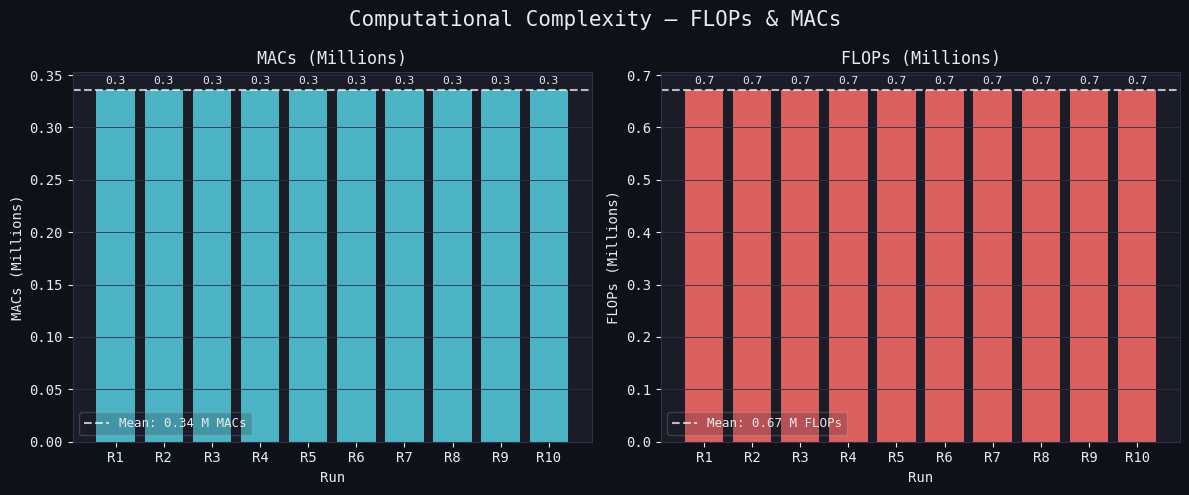

  ✅ saved → /kaggle/working/flops_macs_analysis.png


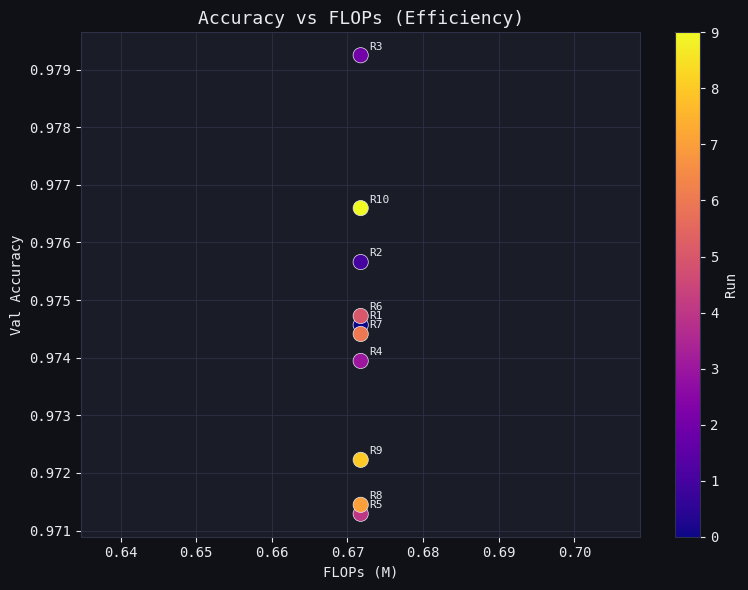

  ✅ saved → /kaggle/working/accuracy_vs_flops.png

  📊 Average Results (VAL) + Complexity:
  Accuracy              : 0.9744
  Loss                  : 0.0823
  MCC                   : 0.9736
  ROC AUC               : 0.9997
  F1 (W)                : 0.9744
  Precision (W)         : 0.9749
  Recall (W)            : 0.9744
  Train Time (s)        : 720.1672
  Infer Total (s)       : 7.9063
  ms / sample           : 1.2336
  Memory (MB)           : 614.1699
  MACs (M)              : 0.3359
  FLOPs (M)             : 0.6717


In [5]:
import gc, time, os, psutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import tensorflow as tf
import tensorflow.keras.backend as K
from sklearn.metrics import (
    matthews_corrcoef, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, f1_score, precision_score, recall_score,
    precision_recall_curve, average_precision_score, roc_curve,
)
from sklearn.preprocessing import label_binarize
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ══════════════════════════════════════════════════════
#  حساب FLOPs و MACs
# ══════════════════════════════════════════════════════
def flops_macs_keras(model, input_shape):
    try:
        from keras_flops import get_flops
        flops = get_flops(model, batch_size=1)
        macs  = flops / 2
        return flops, macs
    except ImportError:
        pass

    total_macs = 0
    for layer in model.layers:
        cfg = layer.get_config()
        try:
            if isinstance(layer, tf.keras.layers.Conv2D):
                out_shape = layer.output.shape
                if len(out_shape) == 4:
                    _, H, W, C_out = out_shape
                    kH, kW = (cfg['kernel_size'] if isinstance(cfg['kernel_size'], (list, tuple))
                              else (cfg['kernel_size'], cfg['kernel_size']))
                    C_in = layer.input.shape[-1]
                    total_macs += H * W * C_out * kH * kW * C_in

            elif isinstance(layer, tf.keras.layers.DepthwiseConv2D):
                out_shape = layer.output.shape
                if len(out_shape) == 4:
                    _, H, W, C = out_shape
                    kH, kW = (cfg['kernel_size'] if isinstance(cfg['kernel_size'], (list, tuple))
                              else (cfg['kernel_size'], cfg['kernel_size']))
                    total_macs += H * W * C * kH * kW

            elif isinstance(layer, tf.keras.layers.Dense):
                in_units  = layer.input.shape[-1]
                out_units = cfg['units']
                total_macs += in_units * out_units

        except Exception:
            continue

    total_flops = total_macs * 2
    return total_flops, total_macs


# ═══════════════════════════════════════════════════════════════
#  إعدادات الحفظ والثيم
# ═══════════════════════════════════════════════════════════════
SAVE_DIR = "/kaggle/working/"
os.makedirs(SAVE_DIR, exist_ok=True)

PALETTE = plt.cm.tab10.colors
BG      = "#0f1117"
CARD    = "#1a1d27"
ACCENT  = "#4f8ef7"
TEXT    = "#e8eaf0"

plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": CARD,
    "axes.edgecolor": "#2e3148", "axes.labelcolor": TEXT,
    "xtick.color": TEXT, "ytick.color": TEXT,
    "text.color": TEXT, "grid.color": "#2e3148",
    "grid.linewidth": 0.6, "font.family": "monospace",
})

def save(name):
    path = os.path.join(SAVE_DIR, name)
    plt.savefig(path, dpi=120, bbox_inches='tight', facecolor=BG)
    plt.show()
    plt.close()
    print(f"  ✅ saved → {path}")


# ═══════════════════════════════════════════════════════════════
#  Storage
# ═══════════════════════════════════════════════════════════════
num_runs             = 10
results              = []
all_histories        = []
all_y_pred           = []
all_y_pred_prob      = []
all_cms              = []
train_times_list     = []
inference_times_list = []
all_test_probs       = []

# ── حساب FLOPs/MACs مرة واحدة ──────────────────────────────
print("🔢 Calculating FLOPs & MACs...")
_temp_model = build_mobilenetv2(input_shape, num_classes)
model_flops, model_macs = flops_macs_keras(_temp_model, input_shape)
del _temp_model; K.clear_session(); gc.collect()

print(f"  MACs  : {model_macs / 1e6:.2f} M  ({model_macs:.0f})")
print(f"  FLOPs : {model_flops / 1e6:.2f} M  ({model_flops:.0f})")


# ═══════════════════════════════════════════════════════════════
#  MAIN LOOP — 10 Runs
# ═══════════════════════════════════════════════════════════════
for run in range(1, num_runs + 1):
    print(f"\n{'─'*45}\n  🚀 Run {run}/{num_runs}\n{'─'*45}")

    start_time = time.time()
    start_mem  = psutil.Process().memory_info().rss / (1024 ** 2)

    model = build_mobilenetv2(input_shape, num_classes)

    early_stop = EarlyStopping(patience=7, restore_best_weights=True, monitor='val_loss')
    lr_reduce  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=0)

    history = model.fit(
        datagen.flow(X_train, y_train, batch_size=64),
        validation_data=(X_val, y_val),
        epochs=20,
        callbacks=[early_stop, lr_reduce],
        verbose=1,
    )

    end_time     = time.time()
    end_mem      = psutil.Process().memory_info().rss / (1024 ** 2)
    train_time   = end_time - start_time
    train_memory = end_mem - start_mem
    train_times_list.append(train_time)

    # ── Inference ───────────────────────────────────────────
    _ = model.predict(X_val[:8], verbose=0)   # warm-up

    inf_start    = time.time()
    y_pred_probs = model.predict(X_val, verbose=0)
    inf_end      = time.time()

    inference_time          = inf_end - inf_start
    inference_per_sample_ms = inference_time / len(X_val) * 1000
    inference_times_list.append(inference_time)

    y_pred = np.argmax(y_pred_probs, axis=1)

    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)

    cm          = confusion_matrix(y_val, y_pred)
    mcc         = matthews_corrcoef(y_val, y_pred)
    y_val_bin   = label_binarize(y_val, classes=np.arange(num_classes))
    try:
        roc_auc = roc_auc_score(y_val_bin, y_pred_probs, average='macro', multi_class='ovr')
    except Exception:
        roc_auc = np.nan
    f1_w        = f1_score(y_val, y_pred, average='weighted')
    precision_w = precision_score(y_val, y_pred, average='weighted')
    recall_w    = recall_score(y_val, y_pred, average='weighted')

    print(f"  Val Acc: {val_acc:.4f}  |  Val Loss: {val_loss:.4f}")
    print(f"  MCC: {mcc:.4f}  |  ROC AUC: {roc_auc:.4f}")
    print(f"  F1(W): {f1_w:.4f}  |  Prec(W): {precision_w:.4f}  |  Rec(W): {recall_w:.4f}")
    print(f"  Train: {train_time:.2f}s  |  Infer Total: {inference_time:.4f}s"
          f"  |  Infer/sample: {inference_per_sample_ms:.4f} ms  |  Mem: {train_memory:.2f} MB")
    print(f"  MACs: {model_macs/1e6:.2f}M  |  FLOPs: {model_flops/1e6:.2f}M")

    # ── Test probabilities ───────────────────────────────────
    _ = model.predict(X_test[:8], verbose=0)   # warm-up
    test_probs = model.predict(X_test, verbose=0)
    all_test_probs.append(test_probs)

    test_probs_path = os.path.join(SAVE_DIR, f"test_probs_run{run}.npy")
    np.save(test_probs_path, test_probs)
    print(f"  💾 Test probs saved → {test_probs_path}  shape: {test_probs.shape}")

    model_path = os.path.join(SAVE_DIR, f"model_run{run}.h5")
    model.save(model_path)

    all_histories.append(history)
    all_y_pred.append(y_pred)
    all_y_pred_prob.append(y_pred_probs)
    all_cms.append(cm)

    results.append({
        "Run":                      run,
        "Val_Accuracy":             val_acc,
        "Val_Loss":                 val_loss,
        "MCC":                      mcc,
        "ROC_AUC":                  roc_auc,
        "F1_Weighted":              f1_w,
        "Precision_Weighted":       precision_w,
        "Recall_Weighted":          recall_w,
        "Training_Time(s)":         train_time,
        "Inference_Total(s)":       inference_time,
        "Inference_ms_per_sample":  inference_per_sample_ms,
        "Memory_Used(MB)":          train_memory,
        "MACs(M)":                  model_macs / 1e6,
        "FLOPs(M)":                 model_flops / 1e6,
    })

    del model, history, y_pred, y_pred_probs, test_probs
    K.clear_session()
    gc.collect()


# ═══════════════════════════════════════════════════════════════
#  mob_test_probs — average الـ 10 runs
# ═══════════════════════════════════════════════════════════════
mob_test_probs = np.stack(all_test_probs, axis=0).mean(axis=0)

np.save(os.path.join(SAVE_DIR, "mob_test_probs.npy"), mob_test_probs)

print(f"\n  ✅ mob_test_probs.npy — Shape: {mob_test_probs.shape}")
sums = mob_test_probs.sum(axis=1)
print(f"  ✔ Probs sum — min: {sums.min():.4f}  max: {sums.max():.4f}")


# ═══════════════════════════════════════════════════════════════
#  AGGREGATE PLOTS
# ═══════════════════════════════════════════════════════════════
df_metrics  = pd.DataFrame(results)
avg_results = df_metrics.mean(numeric_only=True)
run_labels  = [f"R{r}" for r in range(1, num_runs + 1)]

# ── FLOPs / MACs Summary Panel ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor(BG)
fig.suptitle("Computational Complexity — FLOPs & MACs", color=TEXT, fontsize=15)

for ax, col, ylabel, color, unit in [
    (axes[0], "MACs(M)",  "MACs (Millions)",  "#56cfe1", "M MACs"),
    (axes[1], "FLOPs(M)", "FLOPs (Millions)", "#ff6b6b", "M FLOPs"),
]:
    ax.set_facecolor(CARD)
    bars = ax.bar(run_labels, df_metrics[col], color=color, alpha=0.85, edgecolor='none')
    for bar, val in zip(bars, df_metrics[col]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.01,
                f"{val:.1f}", ha='center', va='bottom', fontsize=8, color=TEXT)
    ax.axhline(df_metrics[col].mean(), color='white', lw=1.5, linestyle='--', alpha=0.7,
               label=f"Mean: {df_metrics[col].mean():.2f} {unit}")
    ax.set_xlabel("Run"); ax.set_ylabel(ylabel); ax.set_title(ylabel, color=TEXT)
    ax.legend(fontsize=9, framealpha=0.2); ax.grid(True, axis='y')
    for sp in ax.spines.values(): sp.set_edgecolor("#2e3148")

plt.tight_layout()
save("flops_macs_analysis.png")

# ── Accuracy vs FLOPs ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor(BG); ax.set_facecolor(CARD)
sc = ax.scatter(df_metrics["FLOPs(M)"], df_metrics["Val_Accuracy"],
                c=range(num_runs), cmap="plasma", s=120, zorder=5,
                edgecolors=TEXT, linewidths=0.5)
for _, row in df_metrics.iterrows():
    ax.annotate(f"R{int(row['Run'])}",
                (row["FLOPs(M)"], row["Val_Accuracy"]),
                textcoords="offset points", xytext=(6, 4),
                fontsize=8, color=TEXT)
ax.set_xlabel("FLOPs (M)"); ax.set_ylabel("Val Accuracy")
ax.set_title("Accuracy vs FLOPs (Efficiency)", color=TEXT, fontsize=13)
ax.grid(True)
for sp in ax.spines.values(): sp.set_edgecolor("#2e3148")
plt.colorbar(sc, ax=ax, label="Run")
plt.tight_layout()
save("accuracy_vs_flops.png")


# ═══════════════════════════════════════════════════════════════
#  Excel
# ═══════════════════════════════════════════════════════════════
summary_cols = [
    "Val_Accuracy", "Val_Loss", "MCC", "ROC_AUC", "F1_Weighted",
    "Precision_Weighted", "Recall_Weighted",
    "Training_Time(s)", "Inference_Total(s)",
    "Inference_ms_per_sample", "Memory_Used(MB)",
    "MACs(M)", "FLOPs(M)",
]

excel_path = os.path.join(SAVE_DIR, "mobilenetv2_full_analysis.xlsx")
with pd.ExcelWriter(excel_path) as writer:
    df_metrics.to_excel(writer, sheet_name="All Runs", index=False)
    avg_results.to_frame(name="Average").to_excel(writer, sheet_name="Average")
    df_metrics[summary_cols].describe().round(4).to_excel(writer, sheet_name="Stats")

# ── ملخص نهائي ───────────────────────────────────────────────
print("\n" + "=" * 55)
print("  📊 Average Results (VAL) + Complexity:")
print("=" * 55)
for col, lbl in [
    ("Val_Accuracy",           "Accuracy"),
    ("Val_Loss",               "Loss"),
    ("MCC",                    "MCC"),
    ("ROC_AUC",                "ROC AUC"),
    ("F1_Weighted",            "F1 (W)"),
    ("Precision_Weighted",     "Precision (W)"),
    ("Recall_Weighted",        "Recall (W)"),
    ("Training_Time(s)",       "Train Time (s)"),
    ("Inference_Total(s)",     "Infer Total (s)"),
    ("Inference_ms_per_sample","ms / sample"),
    ("Memory_Used(MB)",        "Memory (MB)"),
    ("MACs(M)",                "MACs (M)"),
    ("FLOPs(M)",               "FLOPs (M)"),
]:
    print(f"  {lbl:<22}: {avg_results[col]:.4f}")
print("=" * 55)

In [6]:
import tensorflow as tf
import pandas as pd
import os

# ── اختار أحسن run بناءً على Val Accuracy ────────────────────
df_metrics = pd.DataFrame(results)
best_run    = int(df_metrics.loc[df_metrics['Val_Accuracy'].idxmax(), 'Run'])
print(f"  🏆 Best Run: {best_run}  (Val Acc: {df_metrics['Val_Accuracy'].max():.4f})")

# ── تحميل الموديل ─────────────────────────────────────────────
model_path = f"/kaggle/working/model_run{best_run}.h5"
model      = tf.keras.models.load_model(model_path)
print(f"  ✅ Model loaded from: {model_path}")
print(f"  📐 Input shape: {model.input_shape}")

  🏆 Best Run: 3  (Val Acc: 0.9792)


  ✅ Model loaded from: /kaggle/working/model_run3.h5
  📐 Input shape: (None, 64, 64, 3)


In [7]:
import numpy as np

# ── تحميل الـ class names ─────────────────────────────────────
class_names = np.load(
    '/kaggle/input/datasets/abozeidmohamed/original-dataset1/label_encoder_classes (2).npy',
    allow_pickle=True
)

print(f"✅ class_names loaded: {class_names}")
print(f"   عدد الكلاسات: {len(class_names)}")

✅ class_names loaded: ['ain' 'al' 'aleff' 'bb' 'dal' 'dha' 'dhad' 'fa' 'gaaf' 'ghain' 'ha' 'haa'
 'jeem' 'kaaf' 'khaa' 'la' 'laam' 'meem' 'nun' 'ra' 'saad' 'seen' 'sheen'
 'ta' 'taa' 'thaa' 'thal' 'toot' 'waw' 'ya' 'yaa' 'zay']
   عدد الكلاسات: 32


✅ class_names loaded — Classes (32): [np.str_('ain'), np.str_('al'), np.str_('aleff'), np.str_('bb'), np.str_('dal'), np.str_('dha'), np.str_('dhad'), np.str_('fa'), np.str_('gaaf'), np.str_('ghain'), np.str_('ha'), np.str_('haa'), np.str_('jeem'), np.str_('kaaf'), np.str_('khaa'), np.str_('la'), np.str_('laam'), np.str_('meem'), np.str_('nun'), np.str_('ra'), np.str_('saad'), np.str_('seen'), np.str_('sheen'), np.str_('ta'), np.str_('taa'), np.str_('thaa'), np.str_('thal'), np.str_('toot'), np.str_('waw'), np.str_('ya'), np.str_('yaa'), np.str_('zay')]
Full input shape: (None, 64, 64, 3)
📐 Input Shape: 64×64×3  |  Classes: 32

🔍 Explaining 6 samples with LIME …



  0%|          | 0/1000 [00:00<?, ?it/s]

[1/6]  True:         toot  |  Pred:         toot (1.00)  |  ✔ SUCCESS  — Focused on hand/sign


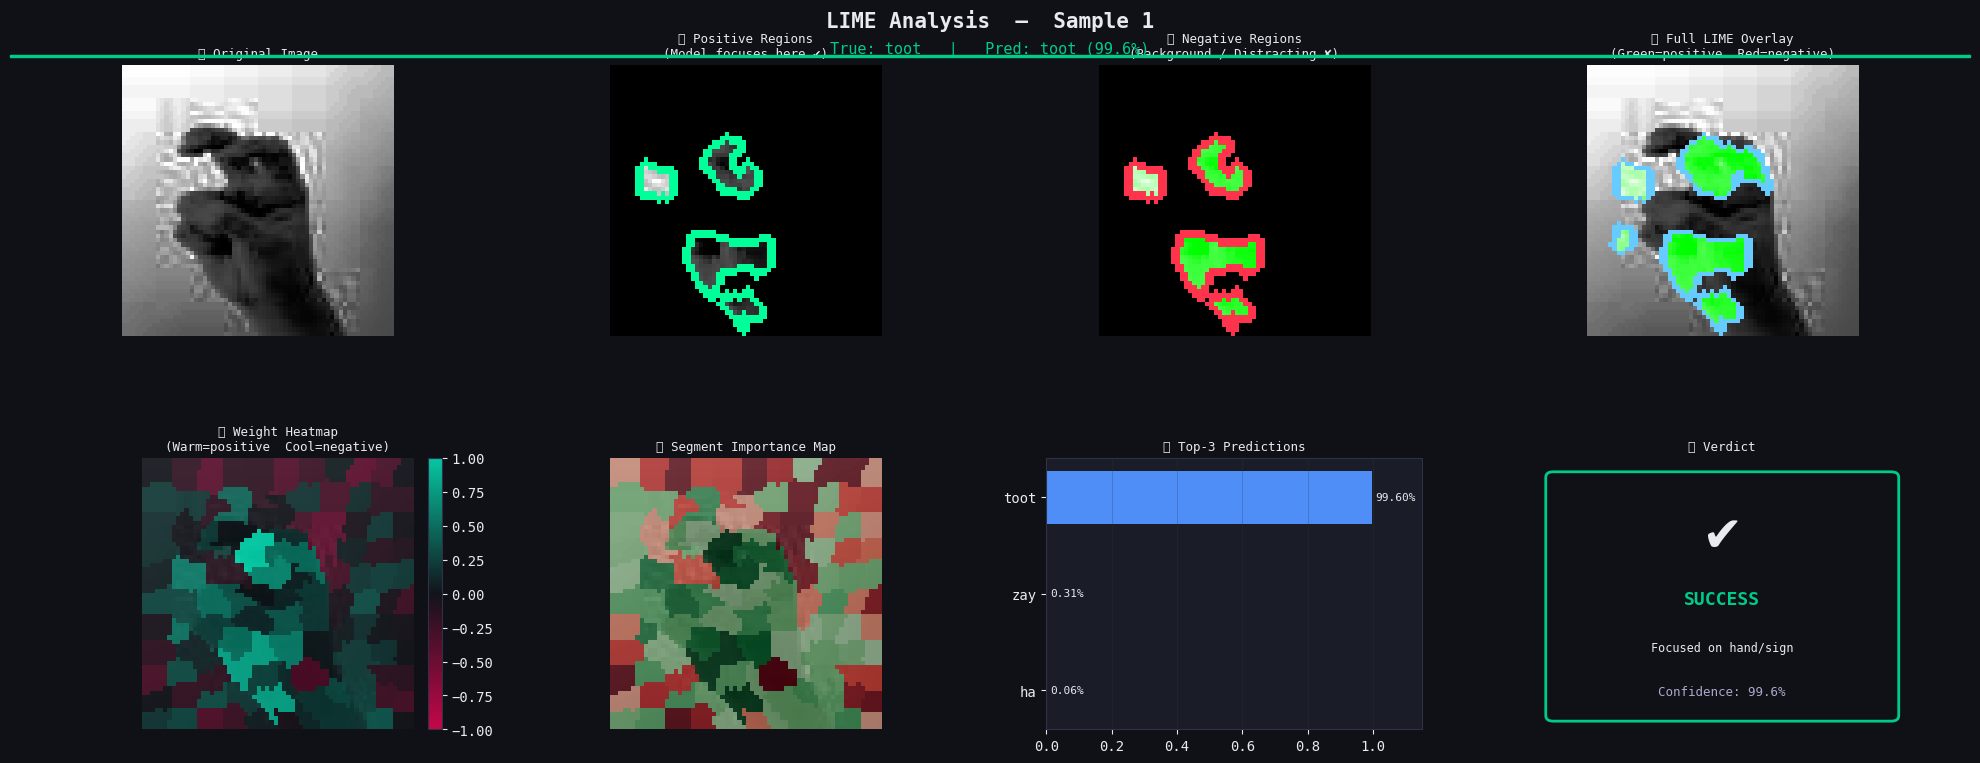

  💾 Saved → /kaggle/working/lime_analysis_sample1.png



  0%|          | 0/1000 [00:00<?, ?it/s]

[2/6]  True:         meem  |  Pred:         meem (1.00)  |  ✔ SUCCESS  — Focused on hand/sign


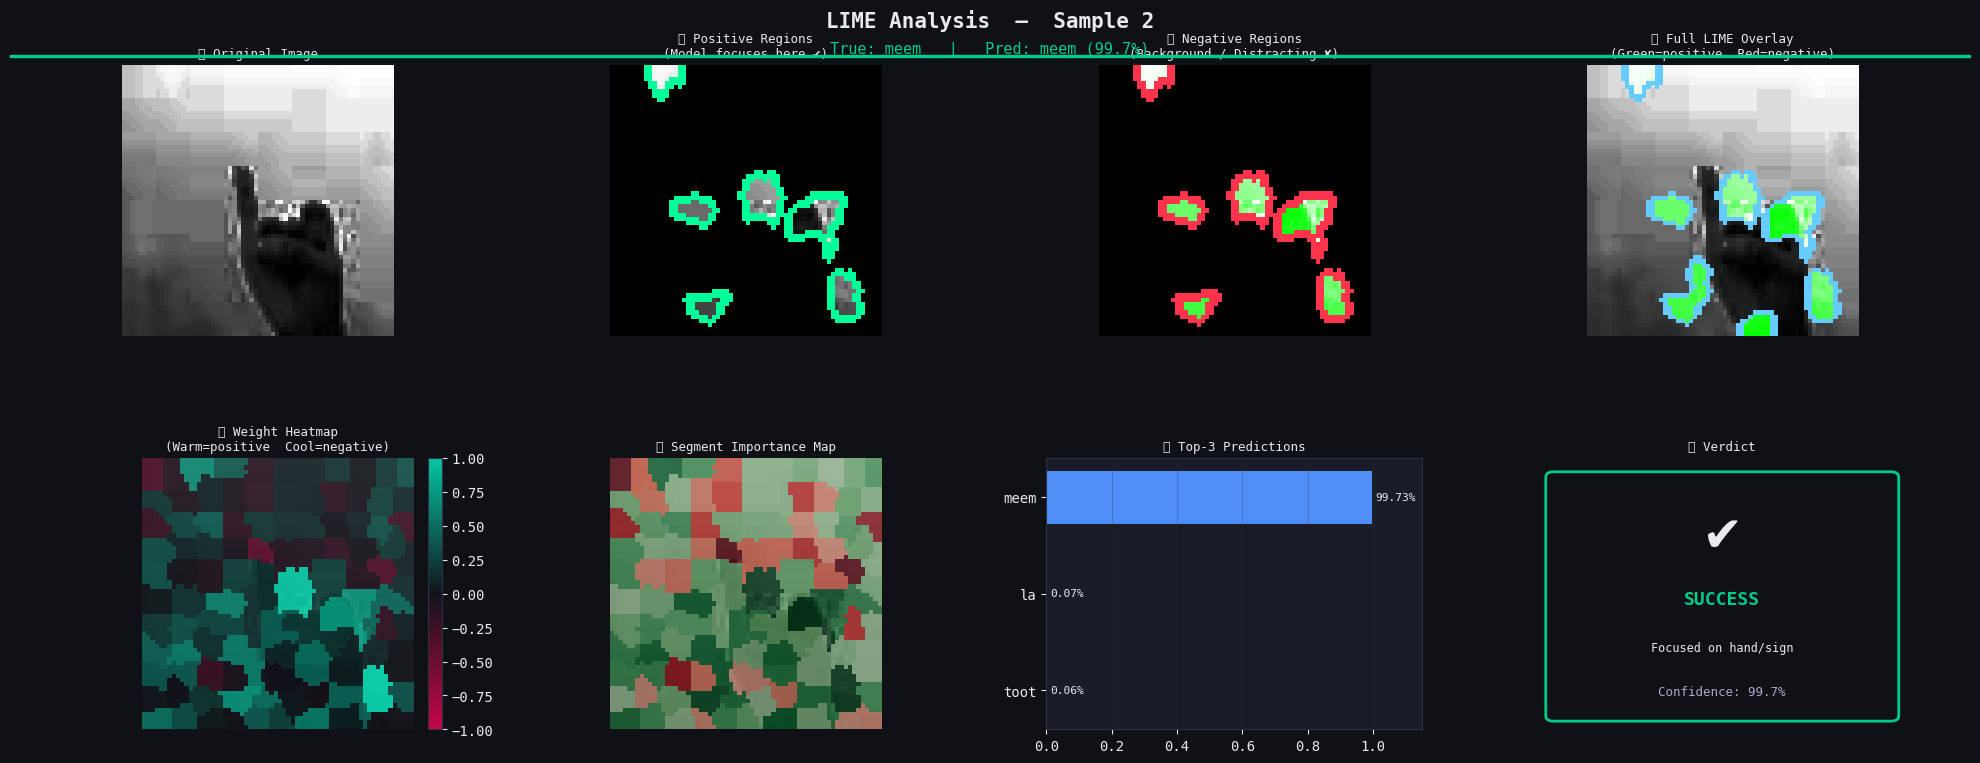

  💾 Saved → /kaggle/working/lime_analysis_sample2.png



  0%|          | 0/1000 [00:00<?, ?it/s]

[3/6]  True:          ain  |  Pred:          ain (1.00)  |  ✔ SUCCESS  — Focused on hand/sign


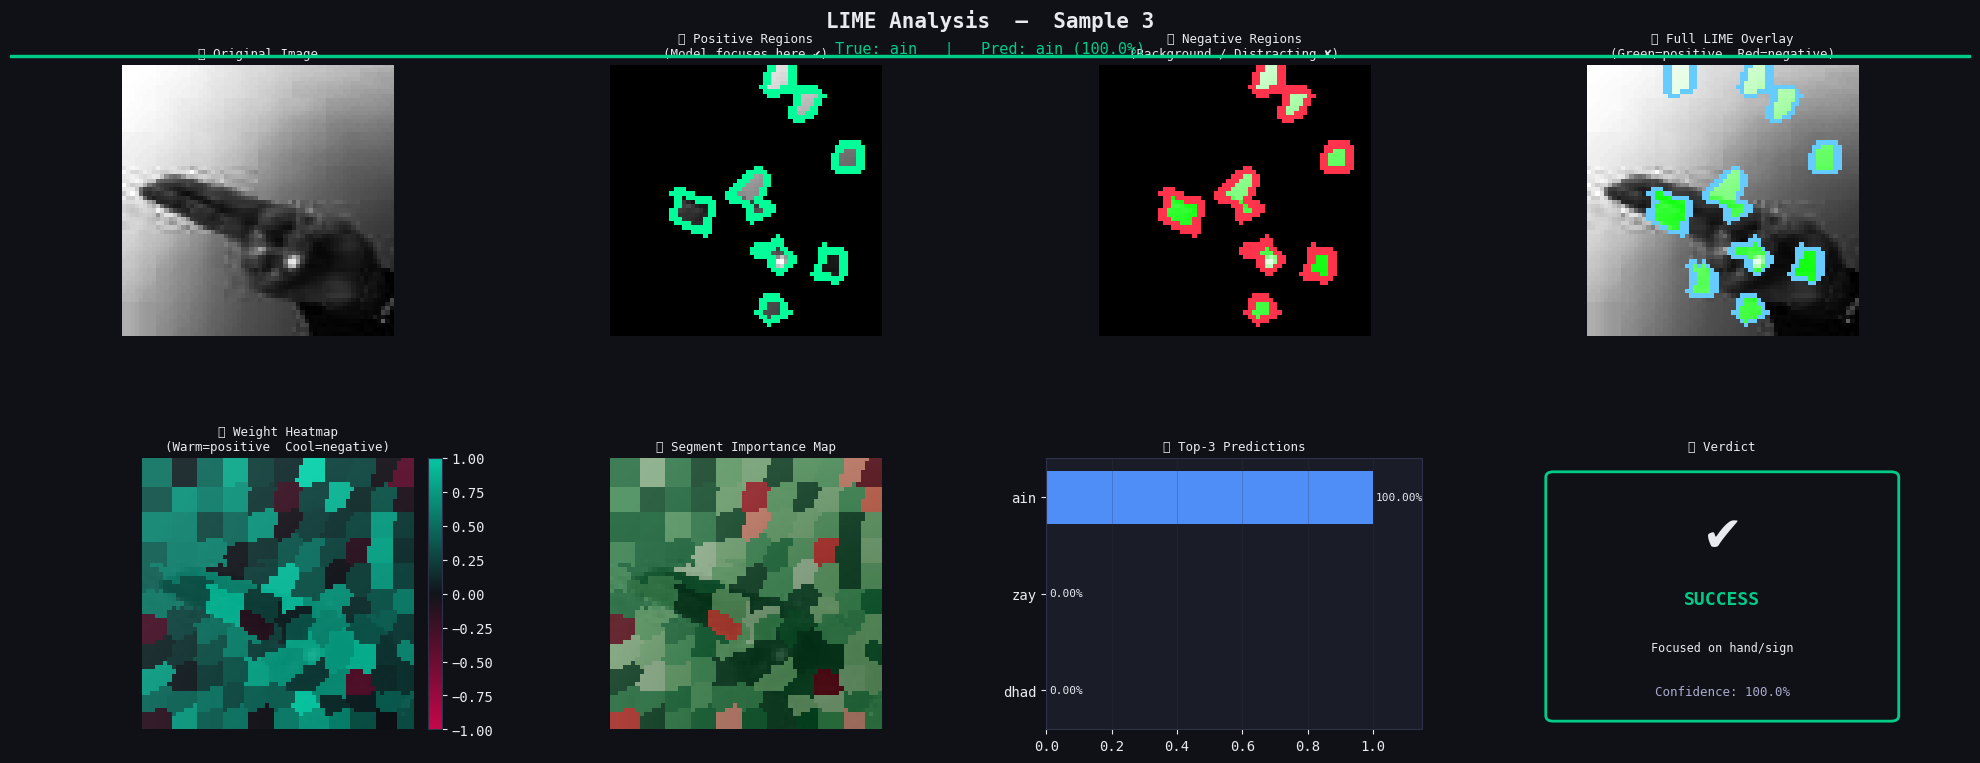

  💾 Saved → /kaggle/working/lime_analysis_sample3.png



  0%|          | 0/1000 [00:00<?, ?it/s]

[4/6]  True:          nun  |  Pred:          nun (0.99)  |  ✔ SUCCESS  — Focused on hand/sign


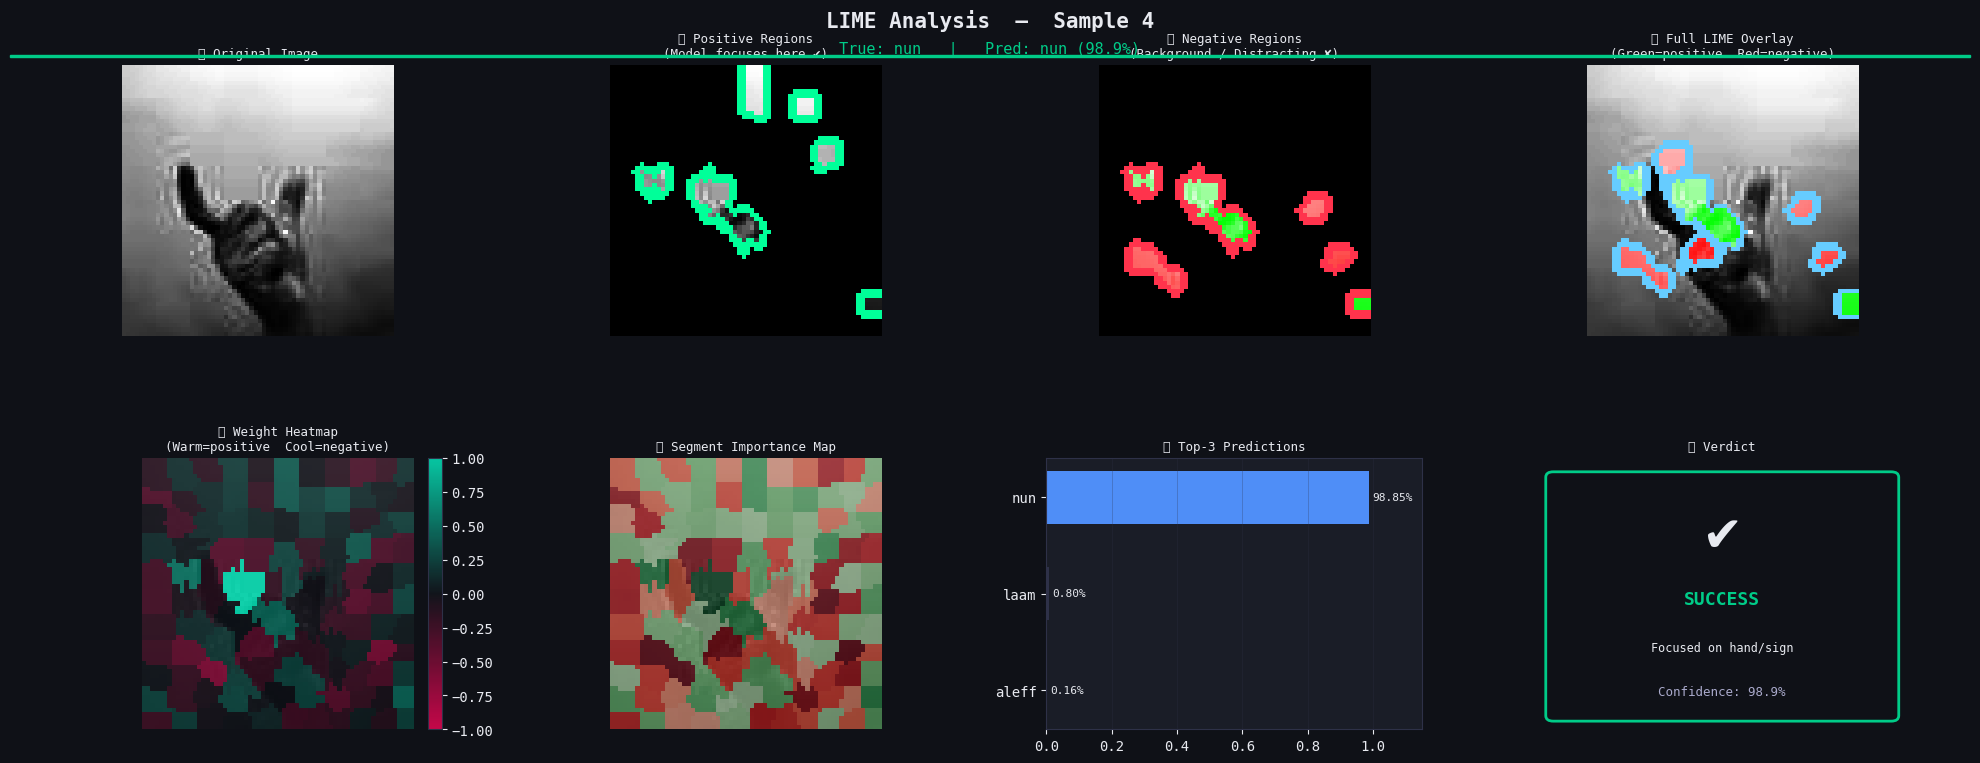

  💾 Saved → /kaggle/working/lime_analysis_sample4.png



  0%|          | 0/1000 [00:00<?, ?it/s]

[5/6]  True:         jeem  |  Pred:         jeem (1.00)  |  ✔ SUCCESS  — Focused on hand/sign


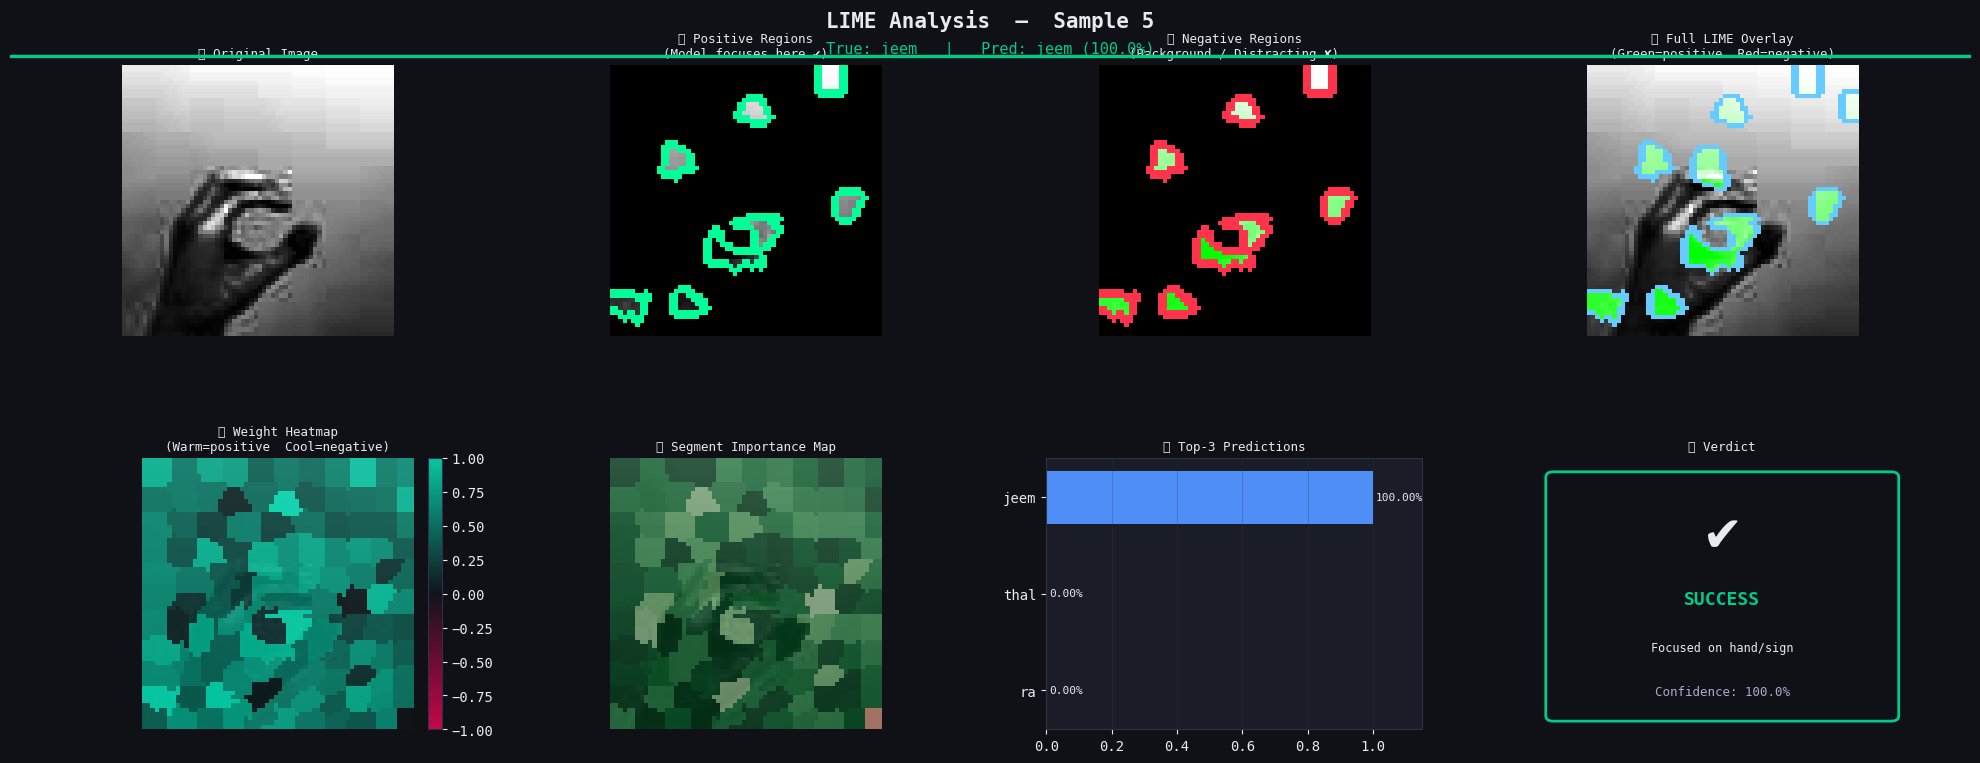

  💾 Saved → /kaggle/working/lime_analysis_sample5.png



  0%|          | 0/1000 [00:00<?, ?it/s]

[6/6]  True:          ain  |  Pred:          ain (1.00)  |  ✔ SUCCESS  — Focused on hand/sign


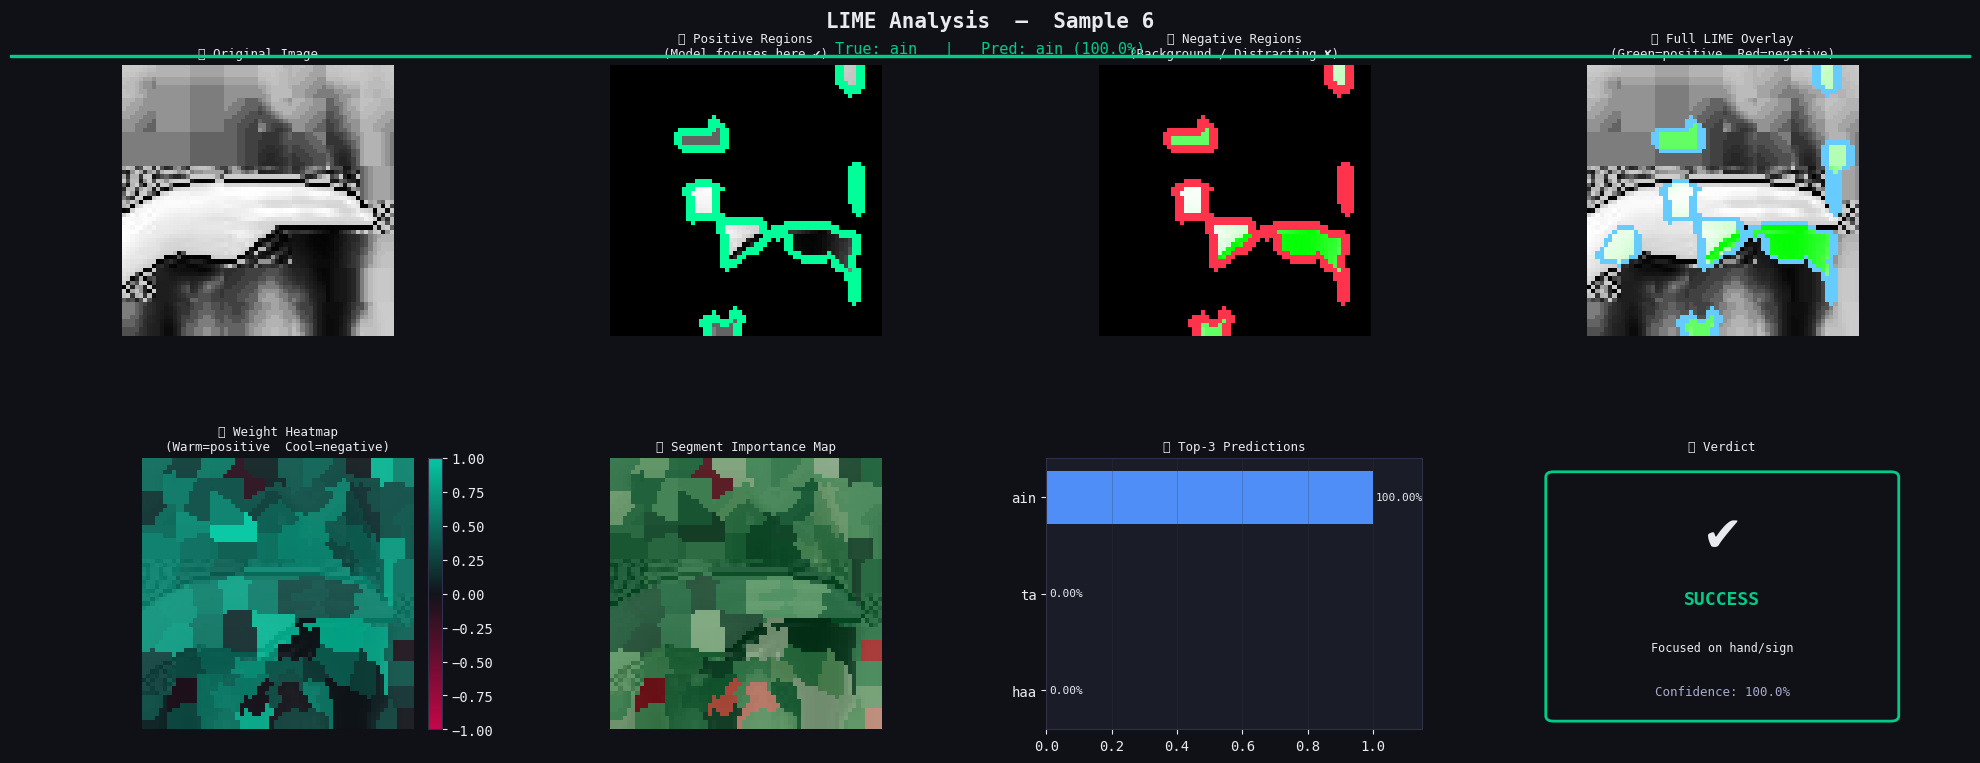

  💾 Saved → /kaggle/working/lime_analysis_sample6.png


═══════════════════════════════════════════════════════
  LIME Analysis Complete
═══════════════════════════════════════════════════════
  Samples explained : 6
  Saved as : /kaggle/working/lime_analysis_sample1.png … lime_analysis_sample6.png
  الصور محفوظة في Output tab على اليمين ☝
═══════════════════════════════════════════════════════


In [9]:
!pip install lime -q

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from lime import lime_image
from skimage.segmentation import mark_boundaries, slic
from skimage.transform import resize
from skimage.color import label2rgb
import warnings
warnings.filterwarnings('ignore')

# ── dark theme ────────────────────────────────────────────────────────────────
BG, CARD, TEXT = "#0f1117", "#1a1d27", "#e8eaf0"
plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": CARD,
    "axes.edgecolor": "#2e3148", "axes.labelcolor": TEXT,
    "xtick.color": TEXT, "ytick.color": TEXT,
    "text.color": TEXT, "font.family": "monospace",
})

# custom heatmap colormaps
CMAP_POS  = LinearSegmentedColormap.from_list("pos",  ["#0f1117", "#4f8ef7", "#00ffcc"])
CMAP_NEG  = LinearSegmentedColormap.from_list("neg",  ["#0f1117", "#f7824f", "#ff0055"])
CMAP_BOTH = LinearSegmentedColormap.from_list("both", ["#ff0055", "#0f1117", "#00ffcc"])

# ── fix naming ────────────────────────────────────────────────────────────────
x_val = X_val
y_val = y_val  # موجود أصلاً

# ── class names & model config ────────────────────────────────────────────────
class_names = np.load('/kaggle/input/datasets/abozeidmohamed/original-dataset1/label_encoder_classes (2).npy', allow_pickle=True)
print(f"✅ class_names loaded — Classes ({len(class_names)}): {list(class_names)}")

# ── FIX: unpack input shape safely ───────────────────────────────────────────
raw_shape = model.input_shape
print(f"Full input shape: {raw_shape}")

if len(raw_shape) == 3:
    H, W, C = raw_shape                  # (64, 64, 1)
elif len(raw_shape) == 4:
    _, H, W, C = raw_shape               # (None, 64, 64, 1)
elif len(raw_shape) == 5:
    _, SEQ, H, W, C = raw_shape          # (None, 10, 64, 64, 1)
else:
    raise ValueError(f"Unexpected input shape: {raw_shape}")

print(f"📐 Input Shape: {H}×{W}×{C}  |  Classes: {len(class_names)}")

# ── helpers ───────────────────────────────────────────────────────────────────
def preprocess_batch(images):
    out = []
    for im in images:
        im = np.asarray(im, dtype="float32")
        if im.ndim == 2:
            im = im[..., np.newaxis]
        if im.shape[-1] != C:
            if C == 1:
                im = np.mean(im[..., :3], axis=-1, keepdims=True)
            else:
                im = np.repeat(im[..., :1], C, axis=-1)
        im = resize(im, (H, W, C), preserve_range=True, anti_aliasing=True).astype("float32")
        if im.max() > 1.0:
            im /= 255.0
        out.append(im)
    arr = np.asarray(out, dtype="float32")               # (batch, H, W, C)
    if len(raw_shape) == 5:
        arr = np.stack([arr] * SEQ, axis=1)              # (batch, SEQ, H, W, C)
    return arr

def to_rgb(image):
    im = np.asarray(image, dtype="float32")
    if im.ndim == 2:
        im = np.stack([im, im, im], axis=-1)
    elif im.shape[-1] == 1:
        im = np.repeat(im, 3, axis=-1)
    im = im[..., :3]
    if im.max() > 1.0:
        im /= 255.0
    return np.clip(im, 0, 1)

def predict_fn(images):
    converted = []
    for im in images:
        im = np.asarray(im, dtype="float32")
        if im.max() > 1.0:
            im /= 255.0
        if C == 1:
            im = np.mean(im[..., :3], axis=-1, keepdims=True)
        im = resize(im, (H, W, C), preserve_range=True, anti_aliasing=True).astype("float32")
        converted.append(im)
    arr = np.asarray(converted, dtype="float32")         # (batch, H, W, C)
    if len(raw_shape) == 5:
        arr = np.stack([arr] * SEQ, axis=1)              # (batch, SEQ, H, W, C)
    return model.predict(arr, verbose=0)

def verdict(true_lbl, pred_lbl, focus_ok):
    if true_lbl != pred_lbl:
        return "❌ FAILURE",  "#ff4d6d", "Wrong prediction"
    if focus_ok:
        return "✔ SUCCESS",  "#00cc88", "Focused on hand/sign"
    return "⚠ PARTIAL",      "#f7824f", "Correct but focused on background"

def is_focused_on_subject(pos_mask):
    if pos_mask.sum() == 0:
        return False
    h, w = pos_mask.shape
    cy, cx = np.argwhere(pos_mask).mean(axis=0)
    return (0.2*h < cy < 0.8*h) and (0.2*w < cx < 0.8*w)

# ── LIME explainer ────────────────────────────────────────────────────────────
explainer = lime_image.LimeImageExplainer(random_state=42)

np.random.seed(42)
n_explain = 6
indices   = np.random.choice(len(x_val), size=n_explain, replace=False)

print(f"\n🔍 Explaining {n_explain} samples with LIME …\n")

for sample_num, idx in enumerate(indices, 1):

    image_raw = x_val[idx]
    if image_raw.ndim == 4:              # (SEQ, H, W, C)
        image = image_raw[0]
    else:
        image = image_raw                # (H, W, C)

    image_rgb = to_rgb(image)
    true_lbl  = int(y_val[idx])

    pred_probs = model.predict(preprocess_batch([image]), verbose=0)[0]
    pred_lbl   = int(np.argmax(pred_probs))
    confidence = pred_probs[pred_lbl]
    top3_idx   = np.argsort(pred_probs)[::-1][:3]

    explanation = explainer.explain_instance(
        image_rgb.astype('double'),
        predict_fn,
        labels=[pred_lbl],
        hide_color=0,
        num_samples=1000,
        segmentation_fn=slic,
    )

    temp_pos, mask_pos = explanation.get_image_and_mask(
        pred_lbl, positive_only=True,  num_features=8,  hide_rest=True)
    temp_neg, mask_neg = explanation.get_image_and_mask(
        pred_lbl, positive_only=False, num_features=8,  hide_rest=True)
    temp_all, mask_all = explanation.get_image_and_mask(
        pred_lbl, positive_only=False, num_features=10, hide_rest=False)

    seg_map    = explanation.segments
    local_exp  = dict(explanation.local_exp[pred_lbl])
    weight_map = np.zeros(seg_map.shape, dtype='float32')
    for seg_id, w in local_exp.items():
        weight_map[seg_map == seg_id] = w
    weight_norm = weight_map / (np.abs(weight_map).max() + 1e-9)

    focus_ok                     = is_focused_on_subject(mask_pos > 0)
    label_str, lbl_color, reason = verdict(true_lbl, pred_lbl, focus_ok)

    print(f"[{sample_num}/{n_explain}]  True: {class_names[true_lbl]:>12}  |  "
          f"Pred: {class_names[pred_lbl]:>12} ({confidence:.2f})  |  {label_str}  — {reason}")

    fig = plt.figure(figsize=(20, 8))
    fig.patch.set_facecolor(BG)
    gs  = gridspec.GridSpec(2, 4, figure=fig,
                            hspace=0.45, wspace=0.30,
                            left=0.04, right=0.96,
                            top=0.88,  bottom=0.05)

    fig.text(0.5, 0.95,
             f"LIME Analysis  —  Sample {sample_num}",
             ha='center', va='top', fontsize=15, color=TEXT, weight='bold')
    fig.text(0.5, 0.91,
             f"True: {class_names[true_lbl]}   |   Pred: {class_names[pred_lbl]} ({confidence:.1%})",
             ha='center', va='top', fontsize=11, color=lbl_color)
    fig.add_artist(plt.Rectangle((0.01, 0.89), 0.98, 0.003,
                                  transform=fig.transFigure,
                                  color=lbl_color, clip_on=False))

    def _ax(row, col, title, img, cmap=None, alpha=1.0, overlay=None):
        ax = fig.add_subplot(gs[row, col])
        ax.set_facecolor(CARD)
        ax.imshow(img, cmap=cmap, alpha=alpha)
        if overlay is not None:
            ax.imshow(overlay[0], cmap=overlay[1], alpha=overlay[2])
        ax.set_title(title, color=TEXT, fontsize=9, pad=6)
        ax.axis('off')
        for sp in ax.spines.values():
            sp.set_edgecolor("#2e3148")
        return ax

    _ax(0, 0, "① Original Image", image_rgb)

    _ax(0, 1,
        "② Positive Regions\n(Model focuses here ✔)",
        mark_boundaries(temp_pos / (temp_pos.max()+1e-9),
                        mask_pos, color=(0, 1, 0.6), mode='thick'))

    _ax(0, 2,
        "③ Negative Regions\n(Background / Distracting ✘)",
        mark_boundaries(temp_neg / (temp_neg.max()+1e-9),
                        mask_neg, color=(1, 0.2, 0.3), mode='thick'))

    _ax(0, 3,
        "④ Full LIME Overlay\n(Green=positive  Red=negative)",
        mark_boundaries(temp_all / (temp_all.max()+1e-9),
                        mask_all, color=(0.4, 0.8, 1.0), mode='outer'))

    ax_hm = fig.add_subplot(gs[1, 0])
    ax_hm.set_facecolor(CARD)
    ax_hm.imshow(image_rgb, alpha=0.35)
    hm = ax_hm.imshow(weight_norm, cmap=CMAP_BOTH, alpha=0.75, vmin=-1, vmax=1)
    plt.colorbar(hm, ax=ax_hm, fraction=0.046, pad=0.04).ax.yaxis.set_tick_params(color=TEXT)
    ax_hm.set_title("⑤ Weight Heatmap\n(Warm=positive  Cool=negative)", color=TEXT, fontsize=9, pad=6)
    ax_hm.axis('off')

    seg_colored = np.zeros((*seg_map.shape, 3), dtype='float32')
    for seg_id in np.unique(seg_map):
        w = local_exp.get(seg_id, 0)
        if w > 0:
            seg_colored[seg_map == seg_id] = plt.cm.Greens(min(w / (weight_map.max()+1e-9) + 0.3, 1.0))[:3]
        else:
            seg_colored[seg_map == seg_id] = plt.cm.Reds(min(-w / (abs(weight_map.min())+1e-9) + 0.3, 1.0))[:3]
    ax_seg = fig.add_subplot(gs[1, 1])
    ax_seg.set_facecolor(CARD)
    ax_seg.imshow(image_rgb, alpha=0.45)
    ax_seg.imshow(seg_colored, alpha=0.6)
    ax_seg.set_title("⑥ Segment Importance Map", color=TEXT, fontsize=9, pad=6)
    ax_seg.axis('off')

    ax_bar = fig.add_subplot(gs[1, 2])
    ax_bar.set_facecolor(CARD)
    bar_colors = ["#4f8ef7" if i == pred_lbl else "#2e3148" for i in top3_idx]
    bars = ax_bar.barh([class_names[i] for i in top3_idx[::-1]],
                       [pred_probs[i] for i in top3_idx[::-1]],
                       color=bar_colors[::-1], edgecolor='none', height=0.55)
    for bar, val in zip(bars, [pred_probs[i] for i in top3_idx[::-1]]):
        ax_bar.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                    f"{val:.2%}", va='center', fontsize=8, color=TEXT)
    ax_bar.set_xlim(0, 1.15)
    ax_bar.set_title("⑦ Top-3 Predictions", color=TEXT, fontsize=9, pad=6)
    ax_bar.grid(axis='x', alpha=0.3)
    for sp in ax_bar.spines.values():
        sp.set_edgecolor("#2e3148")

    ax_v = fig.add_subplot(gs[1, 3])
    ax_v.set_facecolor(CARD)
    ax_v.axis('off')
    ax_v.text(0.5, 0.72, label_str.split()[0], ha='center', va='center',
              fontsize=40, transform=ax_v.transAxes)
    ax_v.text(0.5, 0.48, label_str.split(None,1)[1] if ' ' in label_str else "",
              ha='center', va='center', fontsize=13, color=lbl_color,
              weight='bold', transform=ax_v.transAxes)
    ax_v.text(0.5, 0.30, reason,
              ha='center', va='center', fontsize=8.5, color=TEXT,
              transform=ax_v.transAxes)
    ax_v.text(0.5, 0.14,
              f"Confidence: {confidence:.1%}",
              ha='center', va='center', fontsize=9, color="#aaaacc",
              transform=ax_v.transAxes)
    ax_v.set_title("⑧ Verdict", color=TEXT, fontsize=9, pad=6)
    rect = mpatches.FancyBboxPatch((0.05, 0.05), 0.9, 0.88,
                                    boxstyle="round,pad=0.02",
                                    linewidth=2, edgecolor=lbl_color,
                                    facecolor='none',
                                    transform=ax_v.transAxes, clip_on=False)
    ax_v.add_patch(rect)

    save_file = f"/kaggle/working/lime_analysis_sample{sample_num}.png"
    plt.savefig(save_file, dpi=130, bbox_inches="tight", facecolor=BG)
    plt.show()
    plt.close(fig)
    print(f"  💾 Saved → {save_file}")
    print()

# ── summary ───────────────────────────────────────────────────────────────────
print("\n" + "═"*55)
print("  LIME Analysis Complete")
print("═"*55)
print(f"  Samples explained : {n_explain}")
print(f"  Saved as : /kaggle/working/lime_analysis_sample1.png … lime_analysis_sample{n_explain}.png")
print("  الصور محفوظة في Output tab على اليمين ☝")
print("═"*55)